   age  bought_insurance
0   22                 0
1   25                 0
2   47                 1
3   52                 0
4   46                 1


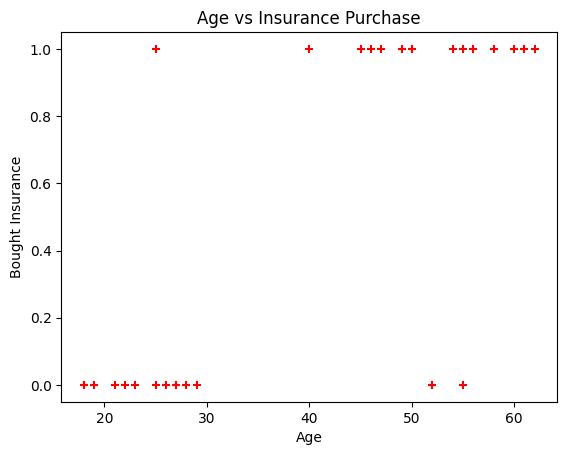

Training shape: (24, 1)
Predicted values: [1 1 0]
Accuracy: 1.0
Probability: [[0.06470655 0.93529345]
 [0.10327333 0.89672667]
 [0.92775258 0.07224742]]
Prediction for age 60: [1]
Coefficient (m): [[0.1274065]]
Intercept (b): [-4.97339194]
Probability for age 35: 0.3742177776690936
Person will NOT buy insurance


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [7]:
# 🔵 LOGISTIC REGRESSION (BINARY CLASSIFICATION)

# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import math

# ==============================
# 2. LOAD DATASET
# ==============================
df = pd.read_csv("insurance_data.csv")

# Fix column spacing issues (important)
df.columns = df.columns.str.strip()

print(df.head())

# ==============================
# 3. VISUALIZATION
# ==============================
plt.scatter(df['age'], df['bought_insurance'], color='red', marker='+')
plt.xlabel("Age")
plt.ylabel("Bought Insurance")
plt.title("Age vs Insurance Purchase")
plt.show()

# ==============================
# 4. TRAIN-TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    df[['age']],
    df['bought_insurance'],
    train_size=0.9,
    random_state=10
)

print("Training shape:", X_train.shape)

# ==============================
# 5. TRAIN MODEL
# ==============================
model = LogisticRegression()
model.fit(X_train, y_train)

# ==============================
# 6. PREDICTIONS
# ==============================
y_predicted = model.predict(X_test)
print("Predicted values:", y_predicted)

# ==============================
# 7. MODEL ACCURACY
# ==============================
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

# ==============================
# 8. PROBABILITY PREDICTION
# ==============================
print("Probability:", model.predict_proba(X_test))

# ==============================
# 9. SINGLE PREDICTION
# ==============================
print("Prediction for age 60:", model.predict([[60]]))

# ==============================
# 10. MODEL PARAMETERS
# ==============================
print("Coefficient (m):", model.coef_)
print("Intercept (b):", model.intercept_)

# ==============================
# 11. SIGMOID FUNCTION (MANUAL)
# ==============================
def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def prediction_function(age):
    z = model.coef_[0][0] * age + model.intercept_[0]
    return sigmoid(z)

# Example
age = 35
prob = prediction_function(age)

print(f"Probability for age {age}:", prob)

if prob < 0.5:
    print("Person will NOT buy insurance")
else:
    print("Person WILL buy insurance")

   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


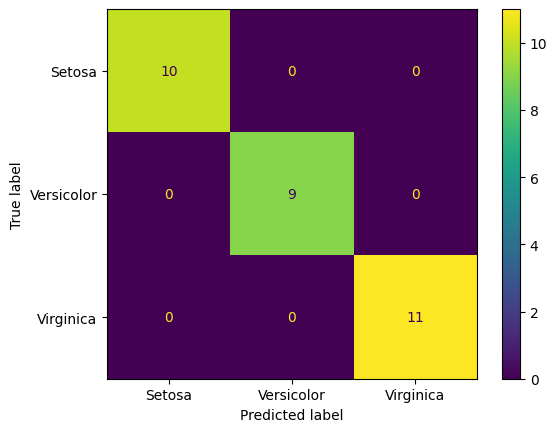

In [10]:
# 🔵 MULTICLASS LOGISTIC REGRESSION (IRIS DATASET)

# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ==============================
# 2. LOAD DATASET
# ==============================
# Make sure iris.csv is uploaded in Colab
df = pd.read_csv("iris (1).csv")

# Fix column spacing issues (important)
df.columns = df.columns.str.strip()

print(df.head())

# ==============================
# 3. FEATURES & TARGET
# ==============================
# Features (all except species)
X = df.drop('species', axis=1)

# Target (class labels)
y = df['species']

# ==============================
# 4. TRAIN-TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 5. TRAIN MODEL
# ==============================
model = LogisticRegression(multi_class='multinomial', max_iter=200)
model.fit(X_train, y_train)

# ==============================
# 6. PREDICTIONS
# ==============================
y_pred = model.predict(X_test)

# ==============================
# 7. ACCURACY
# ==============================
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 2))

# ==============================
# 8. CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Setosa", "Versicolor", "Virginica"]
)

disp.plot()
plt.show()

First 5 Rows:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  


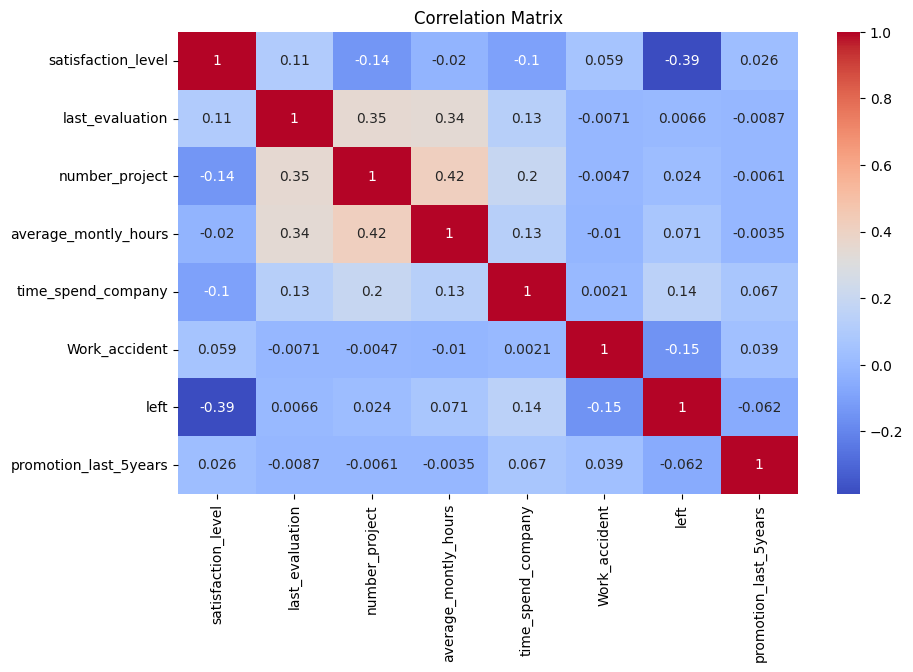

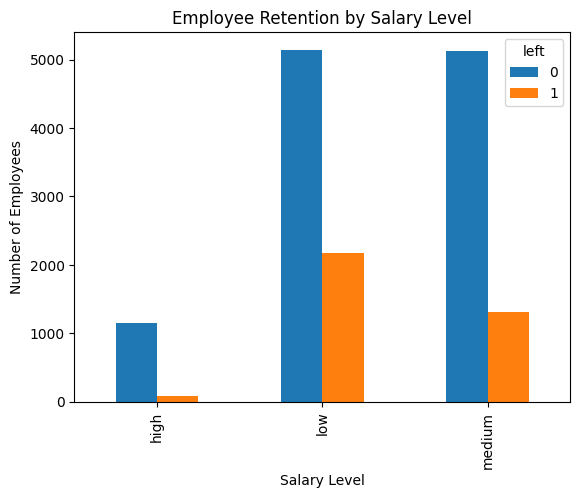

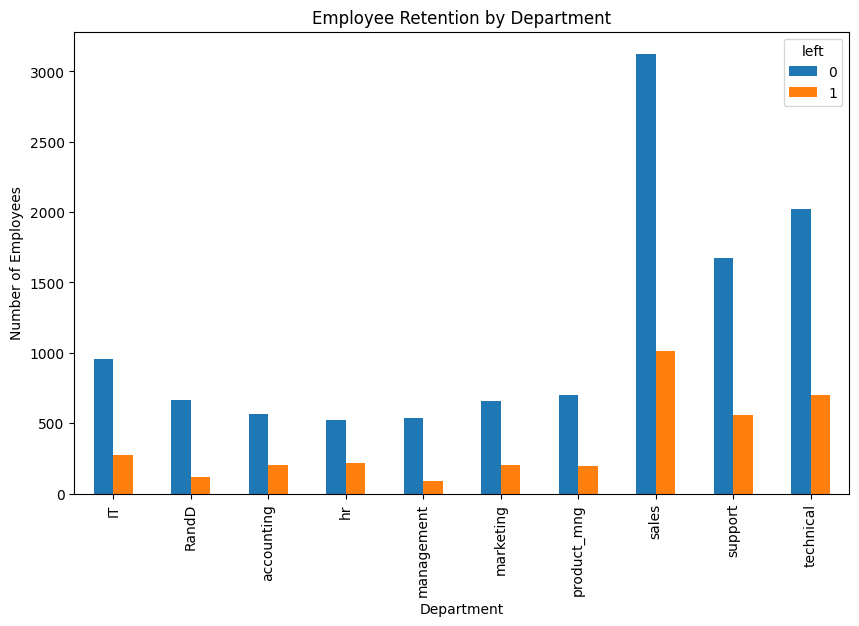


Data after encoding:
   satisfaction_level  average_montly_hours  time_spend_company  \
0                0.38                   157                   3   
1                0.80                   262                   6   
2                0.11                   272                   4   
3                0.72                   223                   5   
4                0.37                   159                   3   

   promotion_last_5years  left  salary_low  salary_medium  Department_RandD  \
0                      0     1        True          False             False   
1                      0     1       False           True             False   
2                      0     1       False           True             False   
3                      0     1        True          False             False   
4                      0     1        True          False             False   

   Department_accounting  Department_hr  Department_management  \
0                  False          

In [11]:
# ==============================
# 1. Import Required Libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ==============================
# 2. Load Dataset
# ==============================

df = pd.read_csv("HR_comma_sep.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nCheck Missing Values:")
print(df.isnull().sum())


# ==============================
# 3. Exploratory Data Analysis
# ==============================

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# ------------------------------
# Salary vs Retention
# ------------------------------

pd.crosstab(df.salary, df.left).plot(kind='bar')

plt.title("Employee Retention by Salary Level")
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.show()

# ------------------------------
# Department vs Retention
# ------------------------------

pd.crosstab(df.Department, df.left).plot(kind='bar', figsize=(10,6))

plt.title("Employee Retention by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.show()


# ==============================
# 4. Feature Selection
# ==============================

# Selecting important features based on EDA
df_model = df[[
    'satisfaction_level',
    'average_montly_hours',
    'time_spend_company',
    'promotion_last_5years',
    'salary',
    'Department',
    'left'
]]


# ==============================
# 5. Encoding Categorical Variables
# ==============================

df_model = pd.get_dummies(df_model, columns=['salary', 'Department'], drop_first=True)

print("\nData after encoding:")
print(df_model.head())


# ==============================
# 6. Define X and y
# ==============================

X = df_model.drop('left', axis=1)
y = df_model['left']


# ==============================
# 7. Train-Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# ==============================
# 8. Build Logistic Regression Model
# ==============================

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


# ==============================
# 9. Make Predictions
# ==============================

y_pred = model.predict(X_test)


# ==============================
# 10. Model Evaluation
# ==============================

accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", round(accuracy * 100, 2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

First 5 rows:
  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   class_type  
0           1  
1           1  
2     

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


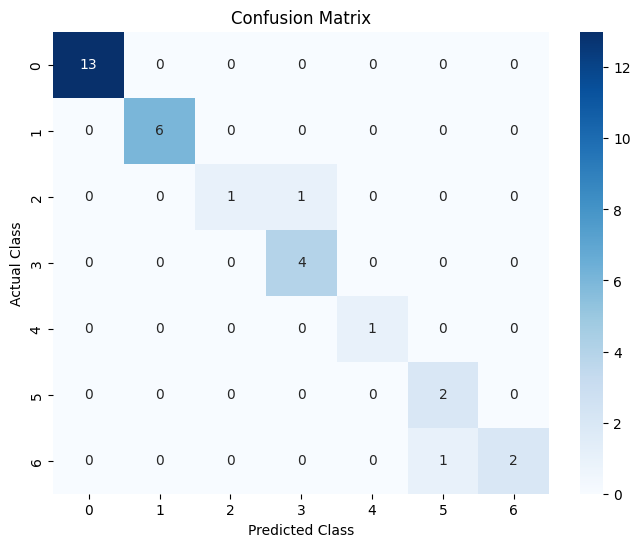

In [12]:
# ==========================================
# 1. Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# ==========================================
# 2. Load Dataset
# ==========================================

df = pd.read_csv("zoo-data.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nCheck Missing Values:")
print(df.isnull().sum())


# ==========================================
# 3. Data Preprocessing
# ==========================================

# animal_name is not useful for prediction → drop it
df = df.drop("animal_name", axis=1)

# Ensure all data is numeric
df = df.apply(pd.to_numeric)

# Separate features and target
X = df.drop("class_type", axis=1)
y = df["class_type"]


# ==========================================
# 4. Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


# ==========================================
# 5. Build Logistic Regression Model
# ==========================================

model = LogisticRegression(max_iter=5000, multi_class='multinomial')
model.fit(X_train, y_train)


# ==========================================
# 6. Make Predictions
# ==========================================

y_pred = model.predict(X_test)


# ==========================================
# 7. Measure Accuracy
# ==========================================

accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ==========================================
# 8. Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()